In [87]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.tree import DecisionTreeClassifier

In [88]:
df=pd.read_csv('Hotel Reservations.csv')
df=df.drop(columns='Booking_ID')



In [89]:
df.isna().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [90]:
df=pd.get_dummies(data=df,drop_first=True)
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online', 'booking_status_Not_Canceled'],
      dtype='object')

In [91]:

Y=df[['booking_status_Not_Canceled']]
X=df.drop(columns='booking_status_Not_Canceled')
X.shape

(36275, 27)

In [92]:
train_X,test_X,train_Y,test_Y=train_test_split(X,Y,random_state=42,test_size=0.2)
print(train_X.shape)

(29020, 27)


In [93]:
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors

In [99]:
lx=[]
ly=[]
for i in range(1,21):
    modal=DecisionTreeClassifier(criterion='entropy',max_depth=i,random_state=42)
    #modal=KNeighborsClassifier(n_neighbors=i)
    modal.fit(train_X,train_Y)
    y_pred=modal.predict(test_X)
    l=confusion_matrix(y_pred,test_Y)
    TN=l[0][0]
    FN=l[0][1]
    FP=l[1][0]
    TP=l[1][1]
    lx.append(i)
    
    acc1=(TN+TP)/(TN+TP+FP+FN)
    ly.append(acc1)
    if acc<acc1:
        acc=acc1
        error=(FN+FP)/(TN+TP+FP+FN)
        sensitivity=TP/(TP+FN)
        specificity=TN/(TN+FP)
        print(i,'depth')

  

4 depth
5 depth
6 depth
7 depth
8 depth
9 depth
10 depth
11 depth
12 depth
14 depth


In [100]:

print(acc,error,sensitivity,specificity)

0.882012405237767 0.11798759476223294 0.919611489977268 0.8067052980132451


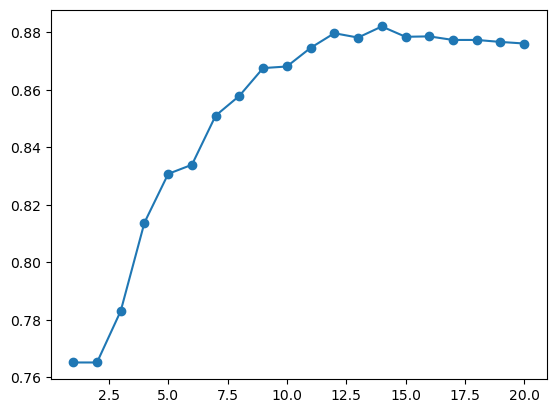

In [101]:
import matplotlib.pyplot as plt
plt.plot(lx,ly,marker='o')
plt.show()